# Data Validation — SystematicTrading

Confirms the FlowsDB loader matches the Excel research data and that Momentum/Carry signals look sensible.

**Run from** `h:/SystematicTrading/systematic-trading/` (the notebook sets paths automatically).

In [1]:
import sys, os, warnings
# Ensure both energy and the app's data layer are importable
_nb_dir = os.path.abspath(os.path.dirname("__file__") or ".")
_app_dir = os.path.abspath(os.path.join(_nb_dir, ".."))
_root    = os.path.abspath(os.path.join(_app_dir, ".."))
for p in [_root, _app_dir]:
    if p not in sys.path:
        sys.path.insert(0, p)

os.environ.setdefault(
    "EXPIRY_CALENDAR_PATH",
    os.path.join(_root, "Systematic_Energy_Trading-main", "data", "expiry_calendars.xlsx"),
)
from dotenv import load_dotenv
load_dotenv(os.path.join(_app_dir, ".env"))

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#12151f", "axes.facecolor": "#12151f",
    "axes.edgecolor": "#2d3142",   "axes.labelcolor": "#9ba3b2",
    "xtick.color": "#9ba3b2",      "ytick.color": "#9ba3b2",
    "text.color": "#d4dae6",       "grid.color": "#1e2235",
    "grid.linestyle": "--",
})
print("Paths OK")


Paths OK


## 1. FlowsDB Loader

One batch pull from `prices_daily` at startup; everything else is served from RAM.

In [2]:
import data.loader as loader

loader.warm_up()
print(f"Loaded {len(loader.loaded_commodities())} commodities:")
print(", ".join(loader.loaded_commodities()))


h:\SystematicTrading\energy\preprocess\expiry_calendar.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  expiries = pd.to_datetime(df[ticker].dropna().astype(str), errors='coerce')
h:\SystematicTrading\energy\preprocess\expiry_calendar.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  expiries = pd.to_datetime(df[ticker].dropna().astype(str), errors='coerce')
h:\SystematicTrading\energy\preprocess\expiry_calendar.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  expiries = pd.to_datetime(df[ticker].dropna().astype(str), errors='coerce')
h:\SystematicTrading\energy\

Loaded 13 commodities:
Brent, Butane, Dubai, Ethane, Gasoil, Murban, Natgas, Propane, RBOB, ULSD, WTI, WTI Houston, WTI Midland


h:\SystematicTrading\energy\preprocess\expiry_calendar.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  expiries = pd.to_datetime(df[ticker].dropna().astype(str), errors='coerce')
h:\SystematicTrading\energy\preprocess\expiry_calendar.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  expiries = pd.to_datetime(df[ticker].dropna().astype(str), errors='coerce')


## 2. Forward Curve Spot Check

Print and plot the WTI curve on the latest available date. Confirms tenors are ordered and prices are plausible.

WTI forward curve — 2026-06-11
col
F1     89.74
F2     88.10
F3     86.31
F4     84.47
F5     82.80
F6     81.43
F7     80.21
F8     79.32
F9     78.10
F10    77.64
F11    77.19
F12    76.57
F13      NaN
F14      NaN
F15      NaN
F16      NaN
F17      NaN
F18    74.24
F19      NaN
F20      NaN
F21      NaN
F22      NaN
F23      NaN
F24    72.37


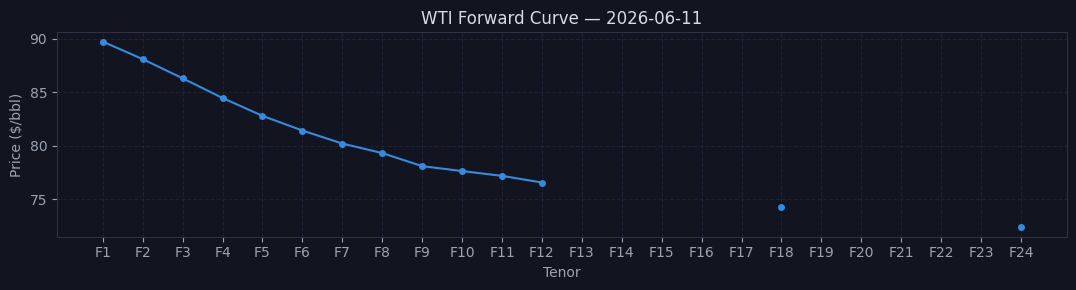

In [3]:
wti    = loader.get_prices("WTI")
latest = wti.iloc[-1]
tenors = [f"F{n}" for n in range(1, 25) if f"F{n}" in latest.index]

print(f"WTI forward curve — {wti.index[-1].date()}")
print(latest[tenors].to_string())

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(tenors, latest[tenors].values, marker="o", ms=4, color="#378ADD", lw=1.5)
ax.set_title(f"WTI Forward Curve — {wti.index[-1].date()}", color="#d4dae6")
ax.set_xlabel("Tenor"); ax.set_ylabel("Price ($/bbl)")
ax.grid(True); plt.tight_layout(); plt.show()


## 3. FlowsDB vs Excel — Correlation Table

Loads the same commodities from the research Excel file and checks the F1 correlation. Expect **corr ≥ 0.9999** for all.

> Scale differences (`db_last` vs `xl_last`) are expected: Excel applies `spec["normalization"]`; FlowsDB stores raw native units. Signal direction is scale-invariant so this has no impact on the monitor.

In [4]:
from energy.preprocess.loaders import load_contract_data

XL_DATA = os.path.join(_root, "Systematic_Energy_Trading-main", "data", "Commods.xlsx")
XL_CAL  = os.path.join(_root, "Systematic_Energy_Trading-main", "data", "expiry_calendars.xlsx")
CHECK   = ["WTI", "Brent", "RBOB", "ULSD", "Gasoil", "Natgas", "Propane", "Ethane", "Butane"]
START   = "2015-01-01"

xl_data = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for name in CHECK:
        try:
            prices, _ = load_contract_data(name, data_path=XL_DATA, calendar_path=XL_CAL)
            xl_data[name] = prices
        except Exception as e:
            print(f"  {name}: Excel load failed — {e}")

print(f"Excel loaded: {list(xl_data.keys())}")


Excel loaded: ['WTI', 'Brent', 'RBOB', 'ULSD', 'Gasoil', 'Natgas', 'Propane', 'Ethane', 'Butane']


In [5]:
rows = []
for name in CHECK:
    db_ok = name in loader.loaded_commodities()
    xl_ok = name in xl_data
    if not db_ok or not xl_ok:
        rows.append(dict(commodity=name, status="MISSING", corr=None,
                         db_end=None, xl_end=None, gap_days=None,
                         db_last=None, xl_last=None)); continue

    db_f1 = loader.get_prices(name).get("F1", pd.Series(dtype=float)).dropna()
    xl_f1 = xl_data[name].get("F1", pd.Series(dtype=float)).dropna()
    db_f1 = db_f1[db_f1.index >= START]
    xl_f1 = xl_f1[xl_f1.index >= START]
    common = db_f1.index.intersection(xl_f1.index)

    if len(common) < 20:
        rows.append(dict(commodity=name, status="NO OVERLAP", corr=None,
                         db_end=None, xl_end=None, gap_days=None,
                         db_last=None, xl_last=None)); continue

    corr = round(float(db_f1.loc[common].corr(xl_f1.loc[common])), 6)
    gap  = (db_f1.index[-1] - xl_f1.index[-1]).days
    rows.append(dict(
        commodity=name,
        status="OK" if corr > 0.999 else ("WARN" if corr > 0.99 else "MISMATCH"),
        corr=corr,
        db_end=str(db_f1.index[-1].date()),
        xl_end=str(xl_f1.index[-1].date()),
        gap_days=gap,
        db_last=round(float(db_f1.iloc[-1]), 4),
        xl_last=round(float(xl_f1.iloc[-1]), 4),
    ))

pd.DataFrame(rows)


,commodity,status,corr,db_end,xl_end,gap_days,db_last,xl_last
0,WTI,OK,1.000000,2026-06-11,2026-06-01,10,89.7400,92.1600
1,Brent,OK,1.000000,2026-06-11,2026-06-01,10,92.5200,95.7400
2,RBOB,OK,1.000000,2026-06-11,2026-06-01,10,313.0500,129.5574
3,ULSD,OK,1.000000,2026-06-11,2026-06-01,10,357.6200,152.8548
4,Gasoil,OK,0.999998,2026-06-11,2026-06-01,10,1035.2500,144.2617
5,Natgas,OK,1.000000,2026-06-11,2026-06-01,10,3.1110,18.4382
6,Propane,OK,1.000000,2026-06-10,2026-06-01,9,0.8092,35.4199
7,Ethane,OK,1.000000,2026-06-10,2026-06-01,9,0.2286,9.0825
8,Butane,OK,1.000000,2026-06-10,2026-04-20,51,1.0587,42.5863


## 4. F1 Overlay Charts

FlowsDB (orange) vs Excel (blue) for all 9 commodities. Curves should be visually identical.

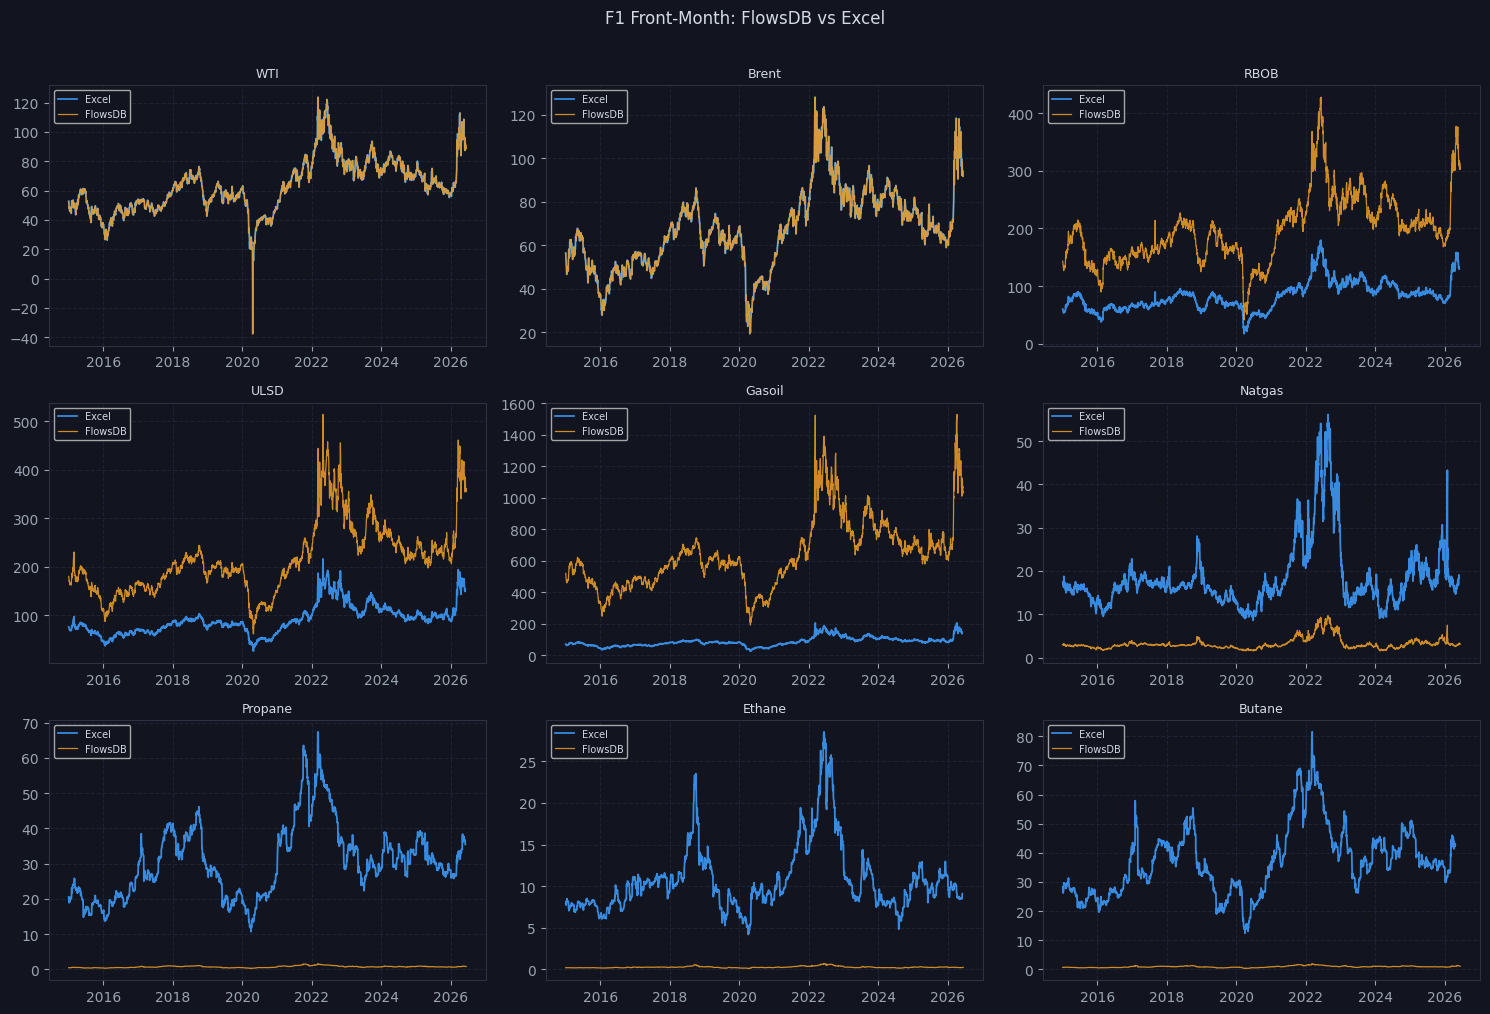

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, name in zip(axes.flatten(), CHECK):
    if name not in xl_data or name not in loader.loaded_commodities():
        ax.set_title(f"{name} — MISSING", color="#E24B4A"); continue

    db_f1 = loader.get_prices(name).get("F1", pd.Series(dtype=float)).dropna()
    xl_f1 = xl_data[name].get("F1", pd.Series(dtype=float)).dropna()
    db_f1 = db_f1[db_f1.index >= START]
    xl_f1 = xl_f1[xl_f1.index >= START]

    ax.plot(xl_f1.index, xl_f1.values, color="#378ADD", lw=1.3, label="Excel")
    ax.plot(db_f1.index, db_f1.values, color="#EF9F27", lw=0.9, alpha=0.85, label="FlowsDB")
    ax.set_title(name, fontsize=9, color="#d4dae6")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True)

plt.suptitle("F1 Front-Month: FlowsDB vs Excel", color="#d4dae6", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 5. Live Signal Snapshot

Runs Momentum + Carry against FlowsDB. This is the exact output the Signals page renders (~20s first run, then cached).

In [7]:
from data.signals import get_live_signal_snapshot, PRODUCT_GROUPS, STRATEGIES
import time

t0  = time.time()
snap = get_live_signal_snapshot()
print(f"Done in {time.time()-t0:.1f}s\n")

rows = []
for group, members in PRODUCT_GROUPS.items():
    basket = {s: snap.get((group, s), ("—", None))[0] for s in STRATEGIES}
    rows.append({"group": group, "commodity": f"[{group} basket]", **basket})
    for m in members:
        row = {s: snap.get((m, s), ("—", None))[0] for s in STRATEGIES}
        rows.append({"group": group, "commodity": m, **row})

pd.DataFrame(rows).set_index(["group", "commodity"])


Done in 1.4s



Momentum Carry
group       commodity                          
Crudes      [Crudes basket]         Short  Long
            WTI                     Short  Long
            Brent                   Short  Long
            Murban                      —     —
            Dubai                       —     —
            WTI Houston                 —     —
            WTI Midland                 —     —
Products    [Products basket]       Short  Long
            ULSD                    Short  Long
            RBOB                    Short  Long
            Gasoil                  Short  Long
            Fuel Oil                    —     —
            Gulf Jet Fuel               —     —
            Eurobob                     —     —
            Naphtha                     —     —
            Japan Naphtha               —     —
NGLs        [NGLs basket]           Short  Long
            Propane                 Short  Long
            Ethane                   Long  Long
            Butane                  Short  Long
Natural Gas [Natural Gas basket]     Long     —
            Natgas                      —     —
            Dutch TTF                   —     —

## 6. Signal History — Single Commodity

Plot price + Momentum + Carry signals over time. Change `COMMODITY` to inspect any asset.

In [8]:
import warnings
from energy.accounting.contract_specs import CONTRACT_SPECS
from energy.accounting.mtm import build_roll_path
from energy.strategies.momentum import momentum
from energy.strategies.carry import carry

COMMODITY   = "WTI"        # ← change me
TRADE_START = "2015-01-01"
MA_PAIRS    = [(1, 5), (5, 20), (10, 60)]
CARRY_FRONT = "F4"
CARRY_END   = "F15"

spec = CONTRACT_SPECS[COMMODITY]
cfg  = spec["prompt_EOM_roll"]

prices_full = loader.get_prices(COMMODITY)
prices      = prices_full[prices_full.index >= TRADE_START].copy()
expiry_cal  = loader.get_expiry(spec["ticker"])
expiry_cal  = expiry_cal[expiry_cal >= pd.Timestamp(TRADE_START)]

roll_kw = dict(
    prices=prices, expiry_calendar=expiry_cal, style=cfg["style"],
    front_col=cfg.get("front_col","F1"), next_col=cfg.get("next_col","F2"),
    third_col=cfg.get("third_col","F3"), far_col=cfg.get("far_col","F4"),
)
if cfg.get("roll_window"): roll_kw["roll_window"] = cfg["roll_window"]
if cfg.get("mid_col"):     roll_kw["mid_col"]     = cfg["mid_col"]
roll_path = build_roll_path(**roll_kw)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mom_path = momentum(prices=prices, rolled_df=roll_path,
                        front_col=cfg.get("front_col","F1"),
                        ma_pairs=MA_PAIRS, prices_signal=prices_full)

carry_path = carry(prices=prices, rolled_df=roll_path,
                   front_col=CARRY_FRONT, end_col=CARRY_END)

print(f"{COMMODITY}  |  Momentum: {mom_path['position'].iloc[-1]:+.0f}  "
      f"Carry: {carry_path['position'].iloc[-1]:+.0f}")


WTI  |  Momentum: -1  Carry: +1


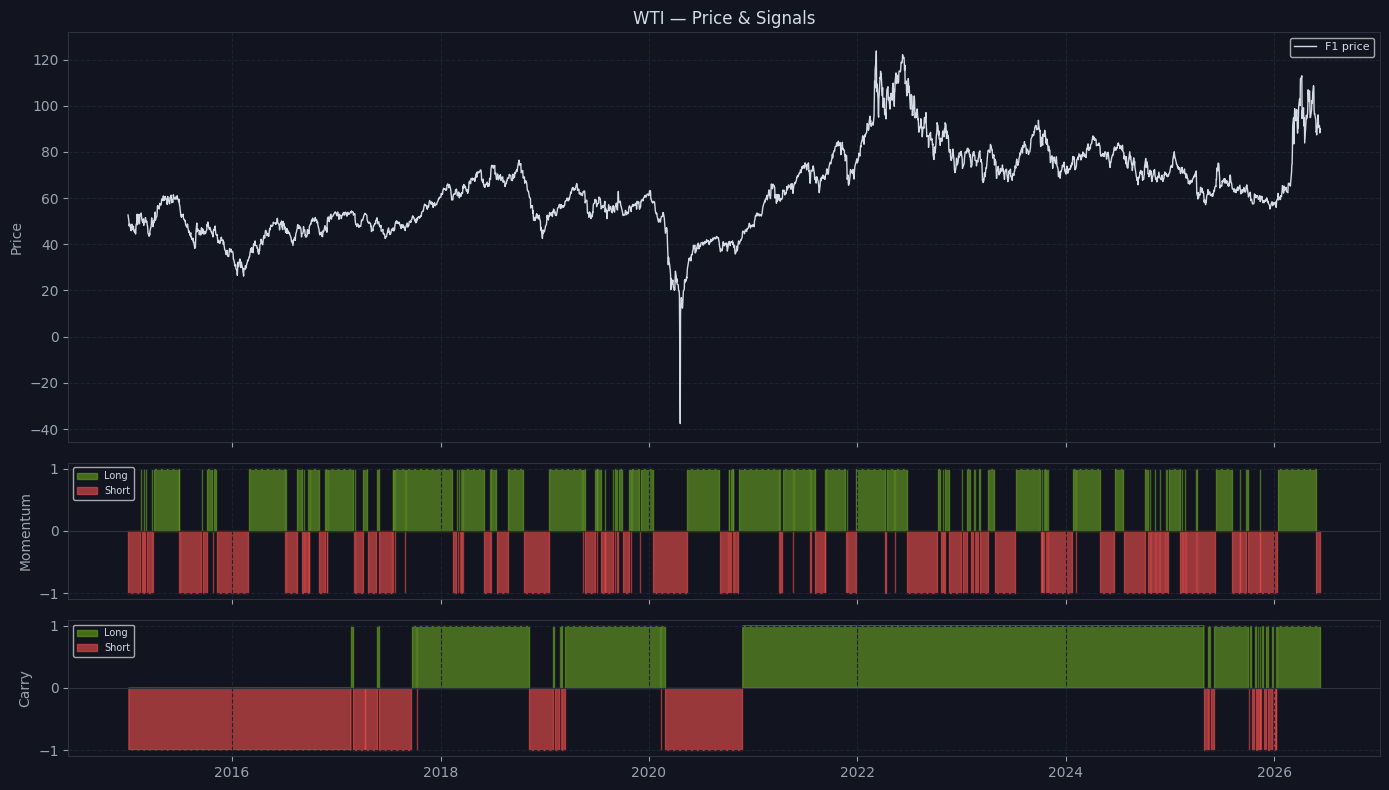

In [9]:
price = prices["F1"].dropna()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8), sharex=True,
                                     gridspec_kw={"height_ratios": [3, 1, 1]})

ax1.plot(price.index, price.values, color="#d4dae6", lw=1, label="F1 price")
ax1.set_ylabel("Price"); ax1.grid(True); ax1.legend(fontsize=8)
ax1.set_title(f"{COMMODITY} — Price & Signals", color="#d4dae6")

for ax, path, label in [
    (ax2, mom_path,   "Momentum"),
    (ax3, carry_path, "Carry"),
]:
    pos = path["position"].reindex(price.index).ffill()
    ax.fill_between(pos.index, pos.values, 0,
        where=pos > 0, color="#639922", alpha=0.65, label="Long")
    ax.fill_between(pos.index, pos.values, 0,
        where=pos < 0, color="#E24B4A", alpha=0.65, label="Short")
    ax.axhline(0, color="#2d3142", lw=0.8)
    ax.set_ylabel(label); ax.set_yticks([-1, 0, 1])
    ax.legend(fontsize=7, loc="upper left"); ax.grid(True)

plt.tight_layout(); plt.show()


## 7. Cross-Check — App Pipeline vs Research Pipeline (Price & PnL)

Runs Momentum and Carry two ways on the same FlowsDB data and compares
the resulting **held-price** series and **PnL/equity** series:

- **research** — mirrors `risk_premia_latest.ipynb`: prices scaled by
  `CONTRACT_SPECS[...]["normalization"]`, `momentum(prices=prices_full, ...)`.
- **app** — mirrors `data/signals.py`: raw (unscaled) FlowsDB prices,
  `momentum(prices=prices, prices_signal=prices_full, ...)`.

Comparison is restricted to the date range both runs share — i.e. **up to how much data we currently have** for that commodity. A `MISMATCH` usually means a normalization or parameter difference between the two code paths (e.g. NGL price scaling).

In [10]:
import re, warnings
from energy.accounting.contract_specs import CONTRACT_SPECS
from energy.accounting.mtm import build_roll_path, build_held_price_series
from energy.accounting.measures import build_measures
from energy.strategies.momentum import momentum
from energy.strategies.carry import carry

XCHECK_PRODUCTS   = ["Butane", "Propane", "Ethane", "WTI", "Brent", "RBOB", "ULSD", "Gasoil", "Natgas"]
XCHECK_TRADE_START = "2015-01-01"
XCHECK_MA_PAIRS    = [(1, 5), (5, 20), (10, 60)]
XCHECK_CARRY_FRONT = "F4"
XCHECK_CARRY_END   = "F15"
XCHECK_CAPITAL     = 1_000_000
XCHECK_VOL_WINDOW  = 120
XCHECK_VOL_TARGET  = 0.15


def _xcheck_warmup_returns(prices_full):
    pre = prices_full.loc[:XCHECK_TRADE_START, "F1"].dropna()
    pre = pre[pre.index < XCHECK_TRADE_START]
    return pre.pct_change().dropna()


def _xcheck_run(commodity, strategy, mode):
    """mode: 'research' (normalized prices, risk_premia_latest call shape)
    or 'app' (raw prices, data/signals.py call shape)."""
    spec = CONTRACT_SPECS.get(commodity, {})
    cfg  = spec.get("prompt_EOM_roll")
    if not cfg:
        return None

    prices_full = loader.get_prices(commodity).copy()
    if mode == "research":
        scale = spec.get("normalization", 1.0)
        if scale and scale != 1.0:
            fcols = [c for c in prices_full.columns if re.match(r"^F\d+$", c)]
            prices_full[fcols] = prices_full[fcols] * scale

    expiry_cal = loader.get_expiry(spec["ticker"])
    prices     = prices_full[prices_full.index >= XCHECK_TRADE_START].copy()
    expiry_cal = expiry_cal[expiry_cal >= XCHECK_TRADE_START]
    if prices.empty or expiry_cal.empty:
        return None

    front_col = cfg.get("front_col", "F1")
    roll_kwargs = dict(
        prices=prices, expiry_calendar=expiry_cal, style=cfg["style"],
        front_col=front_col, next_col=cfg.get("next_col", "F2"),
        third_col=cfg.get("third_col", "F3"), mid_col=cfg.get("mid_col", "F3"),
        far_col=cfg.get("far_col", "F4"),
    )
    if cfg.get("roll_window") is not None:
        roll_kwargs["roll_window"] = cfg["roll_window"]
    roll_path = build_roll_path(**roll_kwargs)

    if strategy == "Momentum":
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            if mode == "research":
                path = momentum(prices=prices_full, rolled_df=roll_path,
                                front_col=front_col, ma_pairs=XCHECK_MA_PAIRS)
            else:
                path = momentum(prices=prices, rolled_df=roll_path,
                                front_col=front_col, ma_pairs=XCHECK_MA_PAIRS,
                                prices_signal=prices_full)
    elif strategy == "Carry":
        if XCHECK_CARRY_END not in prices.columns:
            return None
        path = carry(prices=prices, rolled_df=roll_path,
                     front_col=XCHECK_CARRY_FRONT, end_col=XCHECK_CARRY_END)
    else:
        raise ValueError(strategy)

    held_price = build_held_price_series(path, prices)
    m = build_measures(
        daily_pnl=path["daily_pnl"], ref_price=held_price, signal=path["position"],
        rebalance_flag=path["rebalance_flag"], t_cost_abs=spec.get("t_cost_abs", 0.0),
        initial_capital=XCHECK_CAPITAL, contract_multiplier=spec["contract_multiplier"],
        vol_window=XCHECK_VOL_WINDOW, vol_target_ann=XCHECK_VOL_TARGET,
        warmup_returns=_xcheck_warmup_returns(prices_full),
    )
    return {"held_price": held_price, "capital": m["mtm"]["capital"], "position": path["position"]}


_xcheck_rows = []
for _commodity in XCHECK_PRODUCTS:
    if _commodity not in loader.loaded_commodities():
        continue
    for _strategy in ["Momentum", "Carry"]:
        research = _xcheck_run(_commodity, _strategy, "research")
        app      = _xcheck_run(_commodity, _strategy, "app")

        if research is None or app is None:
            _xcheck_rows.append(dict(commodity=_commodity, strategy=_strategy, status="SKIPPED",
                                     price_corr=None, pnl_corr=None, position_match=None,
                                     common_start=None, common_end=None))
            continue

        common = research["held_price"].index.intersection(app["held_price"].index)
        if len(common) < 20:
            _xcheck_rows.append(dict(commodity=_commodity, strategy=_strategy, status="NO OVERLAP",
                                     price_corr=None, pnl_corr=None, position_match=None,
                                     common_start=None, common_end=None))
            continue

        price_corr = float(research["held_price"].loc[common].corr(app["held_price"].loc[common]))
        pnl_corr   = float(research["capital"].loc[common].corr(app["capital"].loc[common]))
        pos_match  = float((research["position"].loc[common] == app["position"].loc[common]).mean())

        status = "OK" if (price_corr > 0.999 and pnl_corr > 0.999 and pos_match > 0.99) else "MISMATCH"
        _xcheck_rows.append(dict(
            commodity=_commodity, strategy=_strategy, status=status,
            price_corr=round(price_corr, 6), pnl_corr=round(pnl_corr, 6),
            position_match=round(pos_match, 4),
            common_start=str(common.min().date()), common_end=str(common.max().date()),
        ))

xcheck_df = pd.DataFrame(_xcheck_rows)
xcheck_df


,commodity,strategy,status,price_corr,pnl_corr,position_match,common_start,common_end
0,Butane,Momentum,OK,1.0000,1.0000,1.0000,2015-01-02,2026-06-10
1,Butane,Carry,OK,1.0000,1.0000,1.0000,2015-01-02,2026-06-10
2,Propane,Momentum,OK,1.0000,1.0000,1.0000,2015-01-02,2026-06-10
3,Propane,Carry,OK,1.0000,1.0000,1.0000,2015-01-02,2026-06-10
4,Ethane,Momentum,OK,1.0000,1.0000,1.0000,2015-01-02,2026-06-10
5,Ethane,Carry,OK,1.0000,1.0000,1.0000,2015-01-02,2026-06-10
6,WTI,Momentum,OK,1.0000,1.0000,1.0000,2015-01-02,2026-06-11
7,WTI,Carry,OK,1.0000,1.0000,1.0000,2015-01-02,2026-06-11
8,Brent,Momentum,OK,1.0000,1.0000,1.0000,2015-01-02,2026-06-11
9,Brent,Carry,OK,1.0000,1.0000,1.0000,2015-01-02,2026-06-11


### Mismatch detail

For any `MISMATCH` row, overlay the research vs. app held-price and PnL series to see where they diverge.

In [11]:
_mismatches = xcheck_df[xcheck_df["status"] == "MISMATCH"]

for _, row in _mismatches.iterrows():
    commodity, strategy = row["commodity"], row["strategy"]
    research = _xcheck_run(commodity, strategy, "research")
    app      = _xcheck_run(commodity, strategy, "app")
    common   = research["held_price"].index.intersection(app["held_price"].index)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))
    ax1.plot(common, research["held_price"].loc[common], color="#378ADD", lw=1.2, label="research")
    ax1.plot(common, app["held_price"].loc[common], color="#EF9F27", lw=1.2, alpha=0.85, label="app")
    ax1.set_title(f"{commodity} / {strategy} — held price", color="#d4dae6")
    ax1.legend(fontsize=7); ax1.grid(True)

    ax2.plot(common, research["capital"].loc[common], color="#378ADD", lw=1.2, label="research")
    ax2.plot(common, app["capital"].loc[common], color="#EF9F27", lw=1.2, alpha=0.85, label="app")
    ax2.set_title(f"{commodity} / {strategy} — equity (capital)", color="#d4dae6")
    ax2.legend(fontsize=7); ax2.grid(True)

    plt.tight_layout(); plt.show()

if _mismatches.empty:
    print("No mismatches \u2014 app pipeline matches research pipeline for all checked (commodity, strategy) pairs.")


No mismatches — app pipeline matches research pipeline for all checked (commodity, strategy) pairs.


## 8. Dedup Check — `drop_dupes` Effect

`data/loader.py` now runs `drop_dupes()` on each commodity's pivoted F1..F24 frame (drops consecutive rows where F1..F12 are identical — stale/carried-forward settles), before caching. This re-pulls the raw pivoted rows directly from `prices_daily` and compares the row count to what `loader.get_prices()` now serves.

In [12]:
import re as _re
from data.db import query_df
from energy.preprocess.drop_dupes import drop_dupes
from energy.accounting.contract_specs import CONTRACT_SPECS

_dedup_rows = []
for name in loader.loaded_commodities():
    spec = CONTRACT_SPECS.get(name, {})
    root = spec.get("ticker")
    if not root:
        continue

    tickers = [f"{root}{n} Comdty" for n in range(1, 25)]
    raw = query_df(
        """
        SELECT date, bbg_ticker, value FROM prices_daily
        WHERE bbg_ticker = ANY(:tickers) AND field = 'PX_SETTLE'
          AND price_type = 'flat' AND date >= :start_date AND value IS NOT NULL
        ORDER BY date, bbg_ticker
        """,
        {"tickers": tickers, "start_date": "2010-01-01"},
    )
    if raw.empty:
        continue

    raw["date"] = pd.to_datetime(raw["date"])
    raw["n"]    = raw["bbg_ticker"].map(lambda t: int(_re.search(r"(\d+)\s+Comdty$", t).group(1)))
    raw["col"]  = "F" + raw["n"].astype(str)
    wide = raw.pivot_table(index="date", columns="col", values="value", aggfunc="first")
    cols = sorted([c for c in wide.columns if _re.fullmatch(r"F\d+", c)], key=lambda x: int(x[1:]))
    wide = wide[cols]

    deduped = loader.get_prices(name)
    raw_n, dedup_n = len(wide), len(deduped)
    _dedup_rows.append(dict(
        commodity=name,
        raw_rows=raw_n,
        deduped_rows=dedup_n,
        dropped=raw_n - dedup_n,
        pct_dropped=round(100 * (raw_n - dedup_n) / raw_n, 2) if raw_n else None,
    ))

pd.DataFrame(_dedup_rows)


,commodity,raw_rows,deduped_rows,dropped,pct_dropped
0,Brent,4246,4245,1,0.0200
1,Butane,4141,4137,4,0.1000
2,Dubai,1849,1849,0,0.0000
3,Ethane,4141,4130,11,0.2700
4,Gasoil,4246,4244,2,0.0500
5,Murban,1345,1345,0,0.0000
6,Natgas,4142,4139,3,0.0700
7,Propane,4141,4137,4,0.1000
8,RBOB,4142,4139,3,0.0700
9,ULSD,4142,4139,3,0.0700


## 9. Multi-Commodity Alignment — `get_prices_aligned`

`loader.get_prices_aligned(commodities)` reindexes multiple commodities' price frames onto their shared **intersection calendar** (mirrors the `intersection_idx` step from `export_to_excel.py`). Compares each commodity's native row count/range to the aligned (intersection) result.

In [13]:
ALIGN_GROUP = ["WTI", "Brent", "RBOB", "ULSD", "Gasoil", "Natgas", "Propane", "Ethane", "Butane"]
ALIGN_GROUP = [c for c in ALIGN_GROUP if c in loader.loaded_commodities()]

aligned = loader.get_prices_aligned(ALIGN_GROUP)

rows = []
for name in ALIGN_GROUP:
    native = loader.get_prices(name)
    rows.append(dict(
        commodity=name,
        native_rows=len(native),
        native_start=str(native.index.min().date()),
        native_end=str(native.index.max().date()),
        aligned_rows=len(aligned[name]),
    ))

_common = next(iter(aligned.values())).index
print(f"Intersection calendar: {len(_common)} dates "
      f"({_common.min().date()} -> {_common.max().date()})")
pd.DataFrame(rows)


Intersection calendar: 4130 dates (2010-01-04 -> 2026-06-10)


,commodity,native_rows,native_start,native_end,aligned_rows
0,WTI,4139,2010-01-04,2026-06-11,4130
1,Brent,4245,2010-01-04,2026-06-11,4130
2,RBOB,4139,2010-01-04,2026-06-11,4130
3,ULSD,4139,2010-01-04,2026-06-11,4130
4,Gasoil,4244,2010-01-04,2026-06-11,4130
5,Natgas,4139,2010-01-04,2026-06-11,4130
6,Propane,4137,2010-01-04,2026-06-10,4130
7,Ethane,4130,2010-01-04,2026-06-10,4130
8,Butane,4137,2010-01-04,2026-06-10,4130
